In [ ]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read).
The token `sandrazhu` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `sandrazhu`


In [ ]:
pip install transformers datasets torch matplotlib bertopic tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [ ]:
from transformers import pipeline
from datasets import load_dataset
from bertopic import BERTopic
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

2025-08-14 12:20:09,146 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

2025-08-14 12:20:25,858 - BERTopic - Embedding - Completed ✓
2025-08-14 12:20:25,860 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-14 12:20:26,213 - BERTopic - Dimensionality - Completed ✓
2025-08-14 12:20:26,214 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-14 12:20:26,229 - BERTopic - Cluster - Completed ✓
2025-08-14 12:20:26,234 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-14 12:20:26,257 - BERTopic - Representation - Completed ✓


   Topic  Count                  Name  \
0     -1     37     -1_the_and_url_to   
1      0     86      0_the_to_and_for   
2      1     42  1_user_the_for_fight   
3      2     32   2_state_ohio_in_the   

                                      Representation  \
0  [the, and, url, to, in, user, bears, game, of,...   
1   [the, to, and, for, it, series, in, of, url, on]   
2  [user, the, for, fight, to, and, is, in, he, t...   
3  [state, ohio, in, the, to, you, on, and, they,...   

                                 Representative_Docs  
0  [. @Jeremy_White @Sal_Capaccio The one thing I...  
1  [Great day today, my @Las_Vegas_Raiders beat t...  
2  [Anyone who is mad that #tysonvsjones ended in...  
3  [Clemson and Ohio State put on a show in last ...  


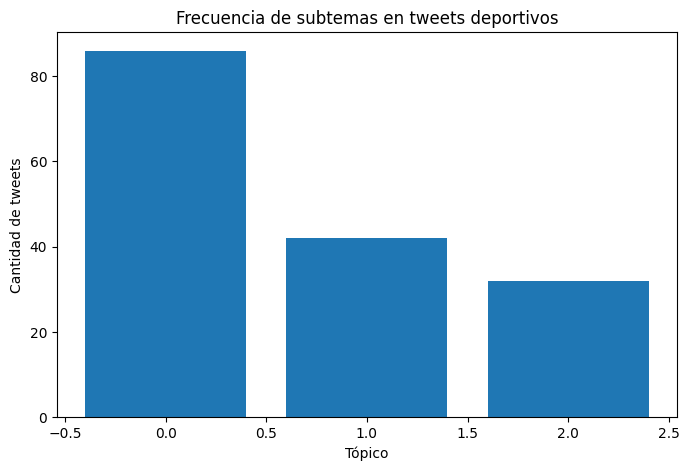

In [ ]:
# 1. Cargar datasets
dataset_topic = load_dataset("cardiffnlp/super_tweeteval", "tweet_topic", split="test")

# 2. Cargar modelo y pipeline de tópicos
topic_model = "cardiffnlp/twitter-roberta-base-topic-latest"
topic_classifier = pipeline("text-classification",
                             model=topic_model,
                             tokenizer=topic_model,
                             return_all_scores=False)

# 3. Clasificar tweets y guardar etiquetas y texto
def clasificar_tweets(dataset, classifier, columna="text", max_tweets=500):
    textos = []
    etiquetas = []
    for i in tqdm(range(min(len(dataset), max_tweets))):
        texto = dataset[i][columna]
        try:
            resultado = classifier(texto)
            etiqueta = resultado[0]['label']
        except:
            etiqueta = "error"
        textos.append(texto)
        etiquetas.append(etiqueta)
    return textos, etiquetas

print("Clasificando temas...")
tweets, temas = clasificar_tweets(dataset_topic, topic_classifier)

# 4. Filtrar solo tweets de deporte
tweets_deporte = [t for t, e in zip(tweets, temas) if e.lower() == "sports"]

print(f"Total tweets analizados: {len(tweets)}")
print(f"Tweets de deporte: {len(tweets_deporte)}")

# 5. Aplicar BERTopic a los tweets deportivos
if len(tweets_deporte) > 0:
    topic_model_bertopic = BERTopic(language="spanish", verbose=True)
    topics, probs = topic_model_bertopic.fit_transform(tweets_deporte)

    # Mostrar información de los subtemas
    print(topic_model_bertopic.get_topic_info())

    # Gráfico estático con matplotlib
    df_topics = topic_model_bertopic.get_topic_info()
    df_topics = df_topics[df_topics.Topic != -1]  # quitar outliers

    plt.figure(figsize=(8,5))
    plt.bar(df_topics['Topic'], df_topics['Count'])
    plt.xlabel("Tópico")
    plt.ylabel("Cantidad de tweets")
    plt.title("Frecuencia de subtemas en tweets deportivos")
    plt.show()

else:
    print("No se encontraron tweets de deporte en el conjunto analizado.")
